# Import libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from keras.layers import Conv2D, MaxPooling2D,Dense,Dropout,Flatten
from keras.models import Sequential
from keras.optimizers import Adam
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

# Data Loading & Preprocessing

In [14]:
import os
print(os.listdir('/'))

['dev', 'lib', 'srv', 'mnt', 'opt', 'tmp', 'usr', 'bin', 'etc', 'home', 'proc', 'lib32', 'media', 'var', 'sbin', 'boot', 'root', 'lib64', 'run', 'libx32', 'sys', 'archive.zip', 'content', 'kaggle', '.dockerenv', 'datalab', 'tools', 'python-apt', 'python-apt.tar.xz', 'NGC-DL-CONTAINER-LICENSE', 'cuda-keyring_1.1-1_all.deb']


In [16]:
import zipfile

with zipfile.ZipFile('//archive.zip', 'r') as zip_ref:
    zip_ref.extractall('//rice_dataset')

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [17]:
import os

print(os.listdir('//rice_dataset'))

['Rice_Image_Dataset']


In [18]:
print(os.listdir('//rice_dataset/Rice_Image_Dataset'))

['Karacadag', 'Jasmine', 'Arborio', 'Ipsala', 'Basmati']


In [27]:
base_path = "/rice_dataset/Rice_Image_Dataset"
classes = {'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}

In [22]:
print(os.listdir('/'))

['dev', 'lib', 'srv', 'mnt', 'opt', 'tmp', 'usr', 'bin', 'etc', 'home', 'proc', 'lib32', 'media', 'var', 'sbin', 'boot', 'root', 'lib64', 'run', 'libx32', 'sys', 'archive.zip', 'content', 'kaggle', 'rice_dataset', '.dockerenv', 'datalab', 'tools', 'python-apt', 'python-apt.tar.xz', 'NGC-DL-CONTAINER-LICENSE', 'cuda-keyring_1.1-1_all.deb']


# Load Image

In [28]:
import os
import cv2

x = []
y = []

# base_path is already set to "/content/rice_dataset/Rice_Image_Dataset" in a previous cell

for cls_name, cls_label in classes.items():
    path = os.path.join(base_path, cls_name)

    for i in os.listdir(path)[:1500]:
        img_path = os.path.join(path, i)

        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (200,200))

        x.append(img)
        y.append(cls_label)

In [29]:
np.unique(y)

array([0, 1, 2, 3, 4])

In [30]:
x = np.array(x)
y = np.array(y)

In [31]:
x.shape

(7500, 200, 200)

# Change Dimension

In [32]:
x = np.expand_dims(x,axis =-1)

In [33]:
x.shape

(7500, 200, 200, 1)

In [34]:
pd.Series(y).value_counts()

,count
0,1500
1,1500
2,1500
3,1500
4,1500


In [35]:
y.shape

(7500,)

# Image Data Splitting

In [47]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [48]:
X_train = X_train/255
X_test = X_test/255

In [49]:
print(X_train)
print(X_test)

[[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.

# CNN Architecture Design (Convolution Layer + Flattening Layer + Fully Connected Layer + Output Layer)

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(200,200,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')   # 5 rice classes
])

In [57]:
model.compile(optimizer = Adam(learning_rate = 0.002),loss='sparse_categorical_crossentropy', metrics = ["accuracy"])

In [58]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 198, 198, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,760,581 (33.42 MB)

 Trainable params: 8,760,581 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
X_train.shape

(6000, 200, 200, 1)

# Model training

In [60]:

model.fit(X_train, y_train, epochs = 20, batch_size = 32, validation_split = 0.2, verbose=1)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.8508 - loss: 0.4101 - val_accuracy: 0.9517 - val_loss: 0.1522
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9360 - loss: 0.1913 - val_accuracy: 0.9692 - val_loss: 0.0990
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9508 - loss: 0.1433 - val_accuracy: 0.9692 - val_loss: 0.0915
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9521 - loss: 0.1332 - val_accuracy: 0.9617 - val_loss: 0.1028
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9546 - loss: 0.1223 - val_accuracy: 0.9617 - val_loss: 0.1092
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9577 - loss: 0.1074 - val_accuracy: 0.9717 - val_loss: 0.1045
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9592 - loss: 0.1119 - val_accuracy: 0.9625 - val_loss: 0.1171
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9685 - loss: 0.0867 - val_acc

# Model Evaluation

In [61]:
y_pred = model.predict(X_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


# Model Accuracy

In [62]:
loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9580 - loss: 0.1732
Test accuracy: 0.9580000042915344


# Accuracy & Loss Plot

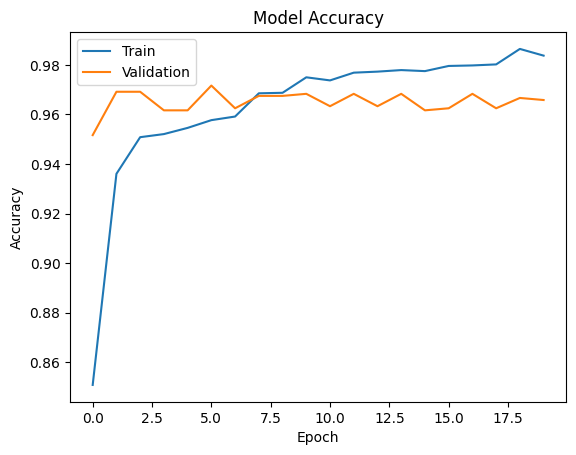

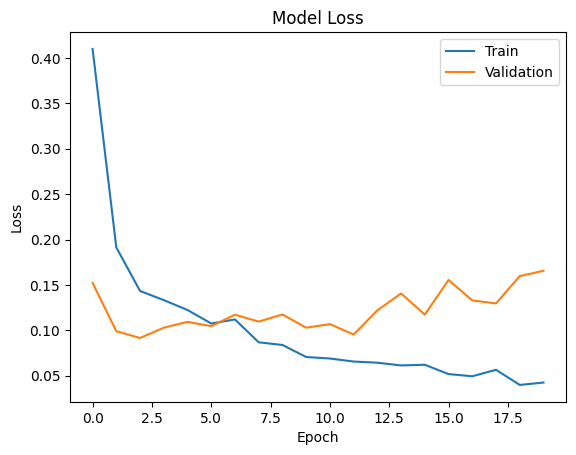

In [63]:
# Accuracy plot
plt.figure()
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.figure()
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Confusion metrix

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


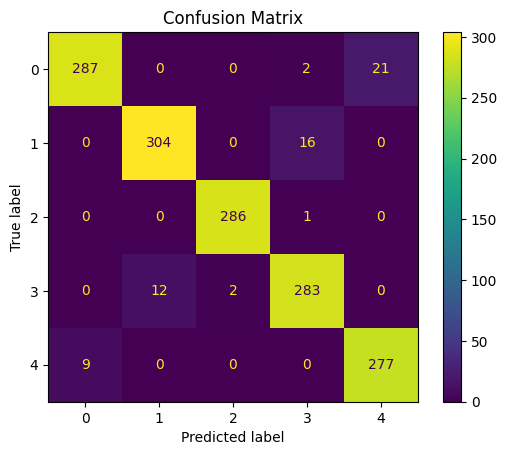

In [64]:
# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Save Model

In [65]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/rice_classification_model.h5")